  # **Predictive Maintenance — AI4I 2020 Dataset**



\# **PHASE** 1 — Setup & **Imports**

In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Sklearn
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, auc,
    f1_score, precision_score, recall_score, accuracy_score,
    matthews_corrcoef, precision_recall_curve, average_precision_score
)

# Imbalanced learning
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Boosting
import xgboost as xgb
import lightgbm as lgb

# Deep Learning
import tensorflow as tf

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Plot style
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = '#f8f9fa'
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
sns.set_palette('husl')

print('All libraries loaded successfully.')

All libraries loaded successfully.


  PHASE 2 —  **Load Dataset**


In [ ]:

# Load the AI4I 2020 dataset
df = pd.read_csv("../ai4i2020.csv")
df.head()

# Show shape and first rows
print(f'Dataset shape: {df.shape}')
print(f'Rows: {df.shape[0]:,} | Columns: {df.shape[1]}')
df.head(10)

# Column info
print('=== Dataset Info ===')
df.info()
print('\n=== Missing Values ===')
print(df.isnull().sum())
print('\n=== Statistical Summary ===')
df.describe().round(3)

# Column names and unique values
for col in df.columns:
    print(f'{col:35s} | dtype: {str(df[col].dtype):10s} | unique: {df[col].nunique()}')




Dataset shape: (10000, 14)
Rows: 10,000 | Columns: 14
=== Dataset Info ===
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  str    
 2   Type                     10000 non-null  str    
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF          

#  PHASE 3 — Exploratory Data Analysis (EDA)


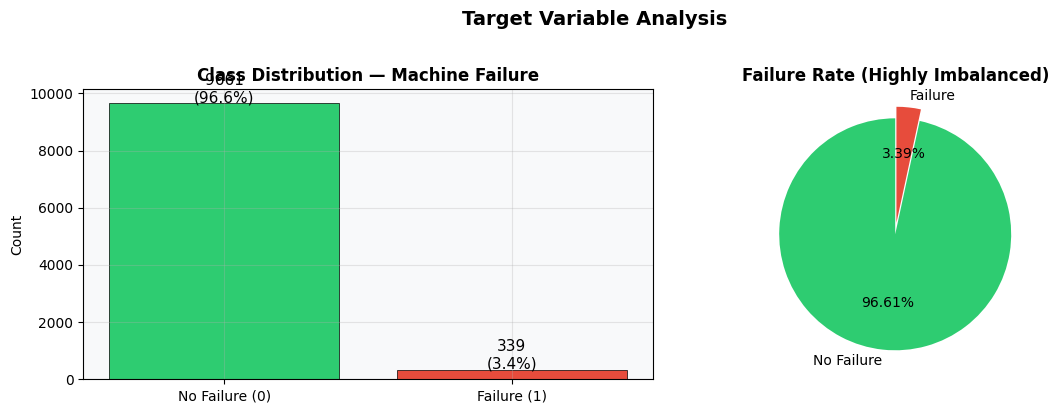

Class imbalance ratio: 28.5:1  (Non-failure : Failure)


In [52]:
# Target class distribution

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df['Machine failure'].value_counts()
axes[0].bar(['No Failure (0)', 'Failure (1)'], counts.values,
            color=['#2ecc71', '#e74c3c'], edgecolor='black', linewidth=0.5)
axes[0].set_title('Class Distribution — Machine Failure', fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 30, f'{v}\n({v/len(df)*100:.1f}%)', ha='center', fontsize=11)

axes[1].pie(counts.values, labels=['No Failure', 'Failure'],
            autopct='%1.2f%%', colors=['#2ecc71', '#e74c3c'],
            startangle=90, explode=(0, 0.1))
axes[1].set_title('Failure Rate (Highly Imbalanced)', fontweight='bold')

plt.suptitle('Target Variable Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'Class imbalance ratio: {counts[0]/counts[1]:.1f}:1  (Non-failure : Failure)')

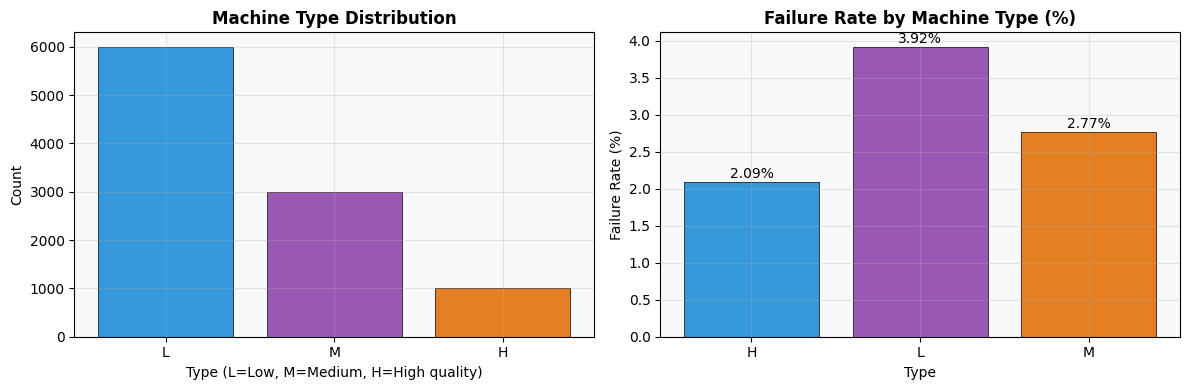

In [53]:
#  Machine Type distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

type_counts = df['Type'].value_counts()
axes[0].bar(type_counts.index, type_counts.values,
            color=['#3498db', '#9b59b6', '#e67e22'], edgecolor='black', linewidth=0.5)
axes[0].set_title('Machine Type Distribution', fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].set_xlabel('Type (L=Low, M=Medium, H=High quality)')

# Failure rate per type
fail_rate = df.groupby('Type')['Machine failure'].mean() * 100
axes[1].bar(fail_rate.index, fail_rate.values,
            color=['#3498db', '#9b59b6', '#e67e22'], edgecolor='black', linewidth=0.5)
axes[1].set_title('Failure Rate by Machine Type (%)', fontweight='bold')
axes[1].set_ylabel('Failure Rate (%)')
axes[1].set_xlabel('Type')
for i, (idx, val) in enumerate(fail_rate.items()):
    axes[1].text(i, val + 0.05, f'{val:.2f}%', ha='center')

plt.tight_layout()
plt.show()



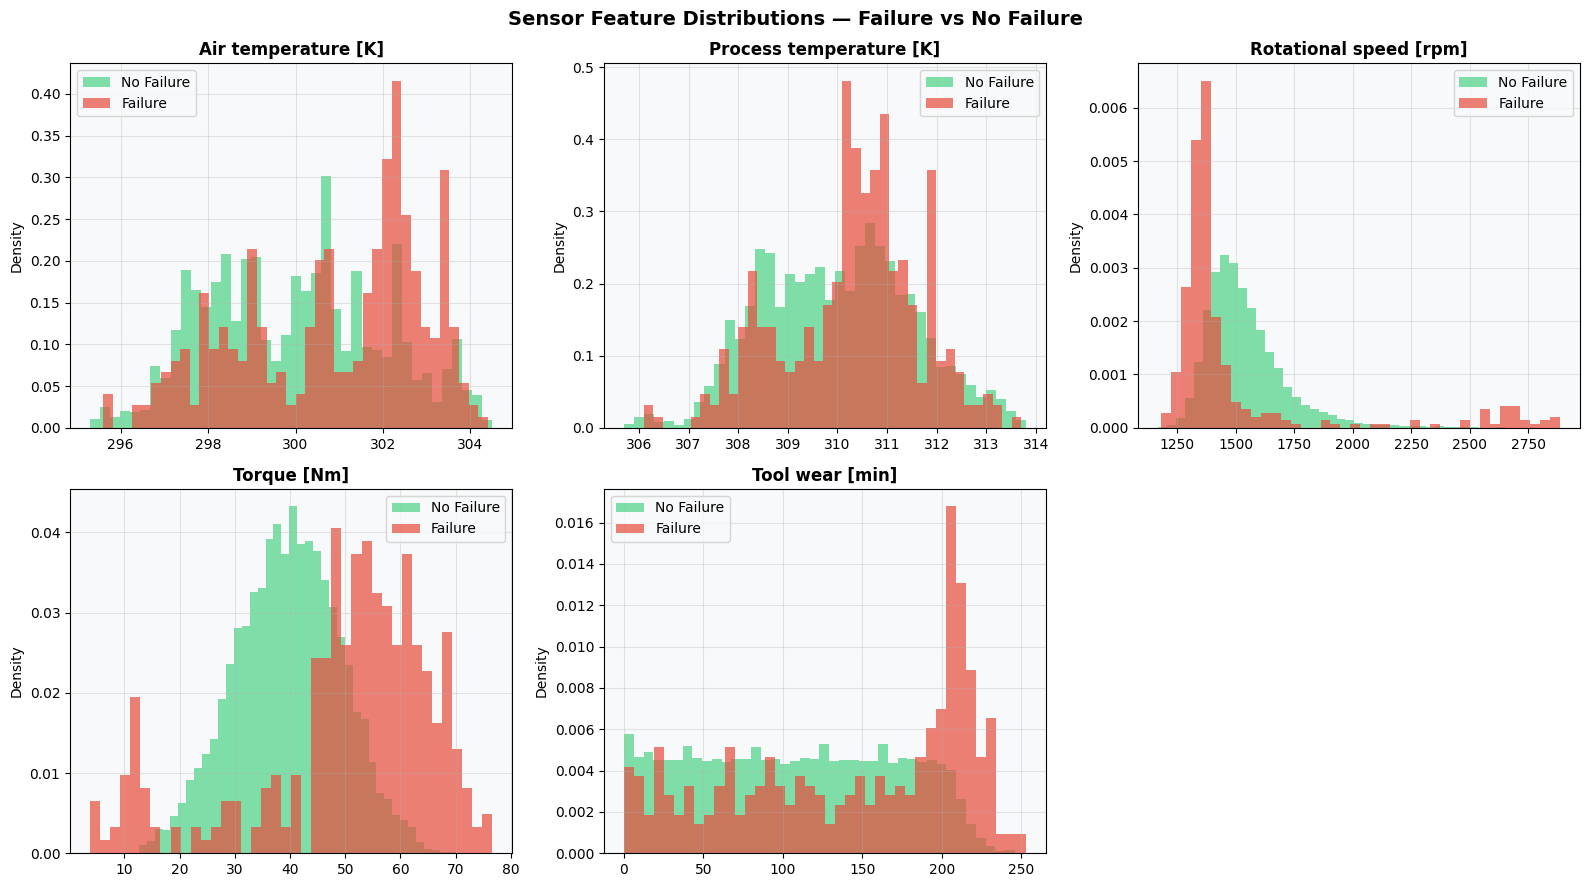

In [54]:
#  Sensor feature distributions — split by failure label
sensor_features = [
    'Air temperature [K]',
    'Process temperature [K]',
    'Rotational speed [rpm]',
    'Torque [Nm]',
    'Tool wear [min]'
]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, feat in enumerate(sensor_features):
    axes[i].hist(df[df['Machine failure']==0][feat], bins=40, alpha=0.6,
                 color='#2ecc71', label='No Failure', density=True)
    axes[i].hist(df[df['Machine failure']==1][feat], bins=40, alpha=0.7,
                 color='#e74c3c', label='Failure', density=True)
    axes[i].set_title(feat, fontweight='bold')
    axes[i].set_ylabel('Density')
    axes[i].legend()

axes[5].axis('off')
plt.suptitle('Sensor Feature Distributions — Failure vs No Failure',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()



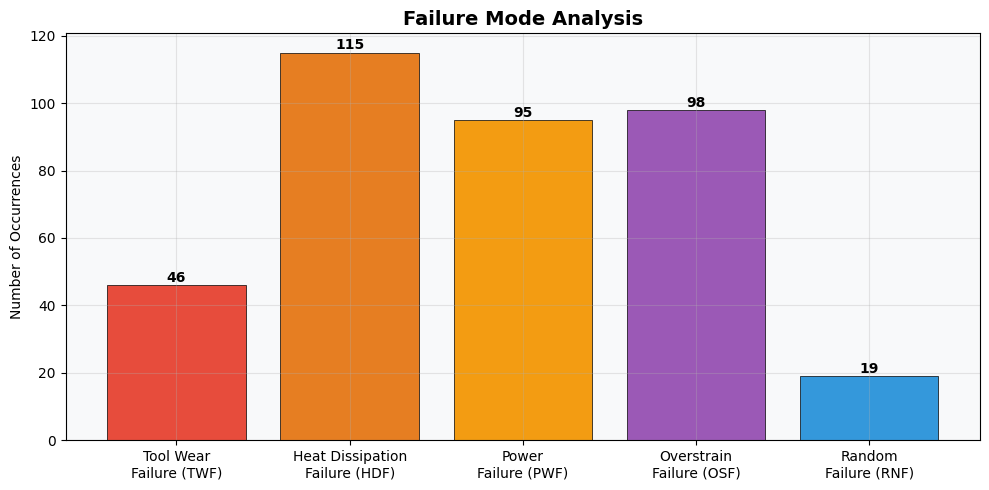

In [55]:
# Failure type breakdown
failure_types = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']
failure_labels = [
    'Tool Wear\nFailure (TWF)',
    'Heat Dissipation\nFailure (HDF)',
    'Power\nFailure (PWF)',
    'Overstrain\nFailure (OSF)',
    'Random\nFailure (RNF)'
]
failure_counts = df[failure_types].sum().values

plt.figure(figsize=(10, 5))
bars = plt.bar(failure_labels, failure_counts,
               color=['#e74c3c','#e67e22','#f39c12','#9b59b6','#3498db'],
               edgecolor='black', linewidth=0.5)
plt.title('Failure Mode Analysis', fontsize=14, fontweight='bold')
plt.ylabel('Number of Occurrences')
for bar, val in zip(bars, failure_counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             str(val), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()



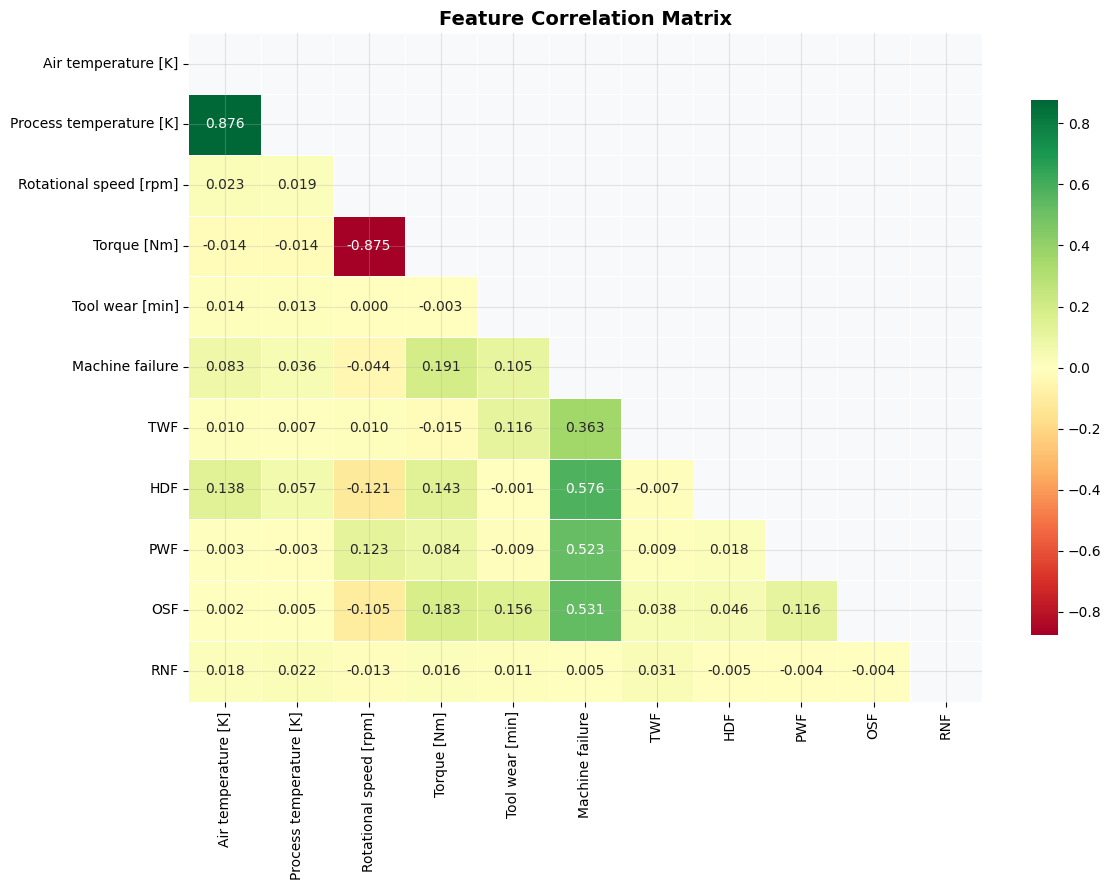

In [56]:
# Correlation heatmap
plt.figure(figsize=(12, 9))
numeric_df = df.drop(['UDI', 'Product ID', 'Type'], axis=1)
corr = numeric_df.corr()

mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.3f', cmap='RdYlGn',
            center=0, linewidths=0.5, linecolor='white',
            cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()



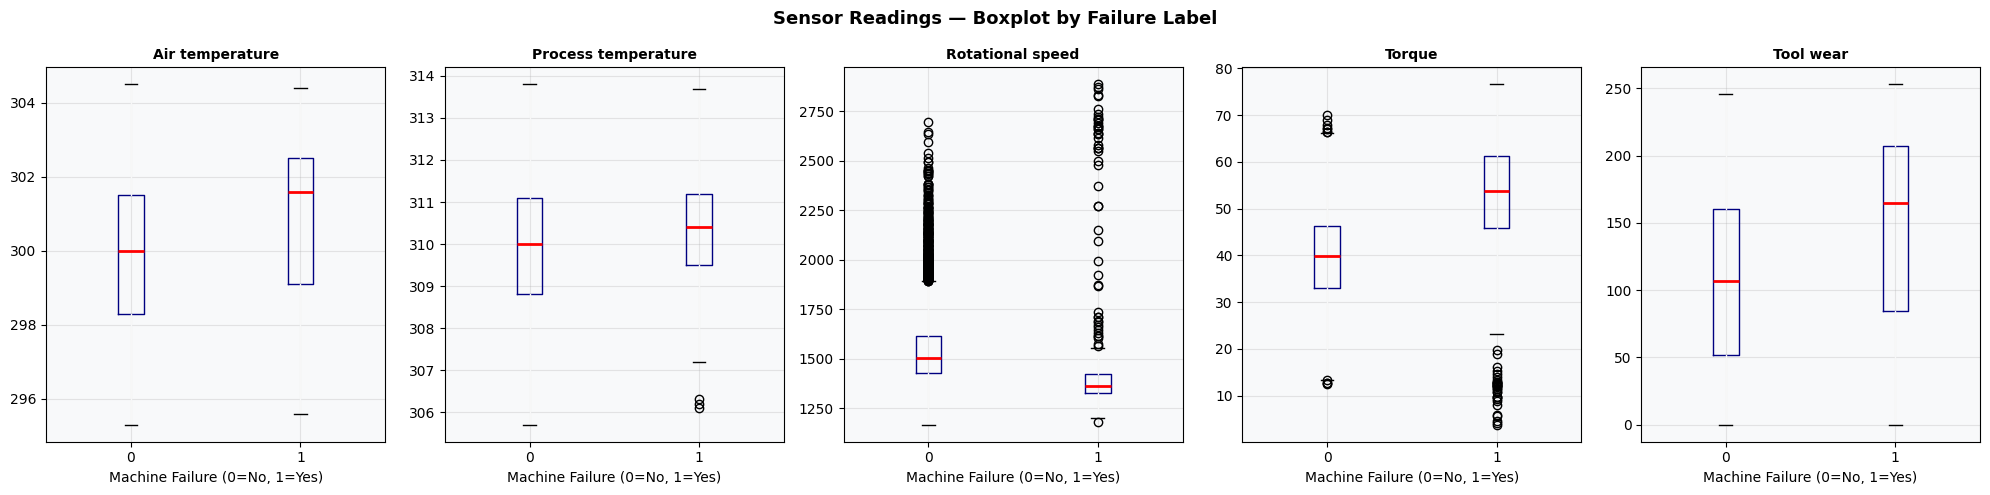

In [57]:
# Boxplots — sensor features vs failure
fig, axes = plt.subplots(1, 5, figsize=(20, 5))
for i, feat in enumerate(sensor_features):
    df.boxplot(column=feat, by='Machine failure', ax=axes[i],
               boxprops=dict(color='navy'),
               medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(feat.split('[')[0].strip(), fontsize=10, fontweight='bold')
    axes[i].set_xlabel('Machine Failure (0=No, 1=Yes)')

plt.suptitle('Sensor Readings — Boxplot by Failure Label', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()



# PHASE 4 — Preprocessing & Feature Engineering

In [58]:

# Encode categorical feature
df_processed = df.copy()
le = LabelEncoder()
df_processed['Type_enc'] = le.fit_transform(df_processed['Type'])
print('Type encoding:', dict(zip(le.classes_, le.transform(le.classes_))))


# Temperature difference (process - air)
df_processed['temp_diff'] = (df_processed['Process temperature [K]']
                             - df_processed['Air temperature [K]'])

# Mechanical power = torque × angular velocity (W)
df_processed['power_W'] = (df_processed['Torque [Nm]']
                           * df_processed['Rotational speed [rpm]']
                           * 2 * np.pi / 60)

# Tool wear rate = wear per unit speed
df_processed['wear_rate'] = (df_processed['Tool wear [min]']
                              / (df_processed['Rotational speed [rpm]'] + 1e-5))

# Torque-to-speed ratio
df_processed['torque_speed_ratio'] = (df_processed['Torque [Nm]']
                                       / (df_processed['Rotational speed [rpm]'] + 1e-5))

# Heat stress index
df_processed['heat_stress'] = (df_processed['Process temperature [K]']
                                * df_processed['Tool wear [min]'] / 1000)

print('New engineered features added:')
new_feats = ['temp_diff', 'power_W', 'wear_rate', 'torque_speed_ratio', 'heat_stress']
print(df_processed[new_feats].describe().round(3))

#Prepare feature matrix and target
feature_cols = [
    'Type_enc',
    'Air temperature [K]',
    'Process temperature [K]',
    'Rotational speed [rpm]',
    'Torque [Nm]',
    'Tool wear [min]',
    'temp_diff',
    'power_W',
    'wear_rate',
    'torque_speed_ratio',
    'heat_stress'
]

X = df_processed[feature_cols]
y = df_processed['Machine failure']

print(f'Feature matrix shape: {X.shape}')
print(f'Target distribution:\n{y.value_counts()}')

#Handle class imbalance with SMOTE
smote = SMOTE(random_state=42, k_neighbors=5)
X_resampled, y_resampled = smote.fit_resample(X, y)

print('Before SMOTE:', dict(y.value_counts()))
print('After  SMOTE:', dict(pd.Series(y_resampled).value_counts()))
print(f'Total samples after SMOTE: {len(X_resampled):,}')

#  Train/Validation/Test split — 70 / 15 / 15
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X_resampled, y_resampled,
    test_size=0.15, random_state=42, stratify=y_resampled
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=0.176, random_state=42, stratify=y_train_full  # 0.176 of 0.85 ≈ 15% total
)

print(f'Train:      {X_train.shape[0]:,} samples')
print(f'Validation: {X_val.shape[0]:,} samples')
print(f'Test:       {X_test.shape[0]:,} samples')

# Feature Scaling
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)

print('Scaling done. Mean ~ 0, Std ~ 1 for all features.')
print(f'Train scaled mean range: [{X_train_sc.mean(axis=0).min():.4f}, {X_train_sc.mean(axis=0).max():.4f}]')




Type encoding: {'H': np.int64(0), 'L': np.int64(1), 'M': np.int64(2)}
New engineered features added:
       temp_diff    power_W  wear_rate  torque_speed_ratio  heat_stress
count  10000.000  10000.000  10000.000           10000.000    10000.000
mean      10.001   6279.745      0.071               0.027       33.467
std        1.001   1067.418      0.043               0.009       19.737
min        7.600   1148.441      0.000               0.001        0.000
25%        9.300   5561.184      0.035               0.021       16.409
50%        9.800   6271.027      0.070               0.027       33.427
75%       11.000   7003.003      0.106               0.033       50.354
max       12.100  10469.923      0.185               0.064       79.012
Feature matrix shape: (10000, 11)
Target distribution:
Machine failure
0    9661
1     339
Name: count, dtype: int64
Before SMOTE: {0: np.int64(9661), 1: np.int64(339)}
After  SMOTE: {0: np.int64(9661), 1: np.int64(9661)}
Total samples after SMOTE: 19

#  PHASE 5 — Baseline ML Models

In [59]:

#  Define and train all baseline models
baseline_models = {
    'Logistic Regression':   LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree':         DecisionTreeClassifier(random_state=42),
    'K-Nearest Neighbors':   KNeighborsClassifier(n_neighbors=5),
    'Random Forest':         RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting':     GradientBoostingClassifier(n_estimators=100, random_state=42),
    'AdaBoost':              AdaBoostClassifier(n_estimators=100, random_state=42),
    'SVM (RBF)':             SVC(kernel='rbf', probability=True, random_state=42),
}

def evaluate_model(name, model, X_tr, y_tr, X_te, y_te, needs_scaled=False):
    Xtr = X_tr
    Xte = X_te
    model.fit(Xtr, y_tr)
    y_pred = model.predict(Xte)
    y_prob = model.predict_proba(Xte)[:, 1]
    return {
        'Model':     name,
        'Accuracy':  round(accuracy_score(y_te, y_pred), 4),
        'Precision': round(precision_score(y_te, y_pred), 4),
        'Recall':    round(recall_score(y_te, y_pred), 4),
        'F1-Score':  round(f1_score(y_te, y_pred), 4),
        'AUC-ROC':   round(roc_auc_score(y_te, y_prob), 4),
        'MCC':       round(matthews_corrcoef(y_te, y_pred), 4),
    }

trained_models = {}

print('Training baseline models...')
baseline_results = []
for name, model in baseline_models.items():
    res = evaluate_model(name, model, X_train_sc, y_train, X_test_sc, y_test)
    # Store trained model
    trained_models[name] = model
    baseline_results.append(res)
    print(f'  ✓ {name:30s} | F1={res["F1-Score"]:.4f} | AUC={res["AUC-ROC"]:.4f}')

baseline_df = pd.DataFrame(baseline_results).set_index('Model')
print('\n=== BASELINE RESULTS ===')
baseline_df.sort_values('AUC-ROC', ascending=False)

# ---


Training baseline models...
  ✓ Logistic Regression            | F1=0.8711 | AUC=0.9409
  ✓ Decision Tree                  | F1=0.9657 | AUC=0.9655
  ✓ K-Nearest Neighbors            | F1=0.9523 | AUC=0.9842
  ✓ Random Forest                  | F1=0.9798 | AUC=0.9982
  ✓ Gradient Boosting              | F1=0.9520 | AUC=0.9911
  ✓ AdaBoost                       | F1=0.9216 | AUC=0.9771
  ✓ SVM (RBF)                      | F1=0.9407 | AUC=0.9840

=== BASELINE RESULTS ===


,Accuracy,Precision,Recall,F1-Score,AUC-ROC,MCC
Model,,,,,,
Random Forest,0.9796,0.9734,0.9862,0.9798,0.9982,0.9594
Gradient Boosting,0.9517,0.9468,0.9572,0.9520,0.9911,0.9035
K-Nearest Neighbors,0.9507,0.9213,0.9855,0.9523,0.9842,0.9035
SVM (RBF),0.9396,0.9235,0.9586,0.9407,0.9840,0.8799
AdaBoost,0.9224,0.9310,0.9124,0.9216,0.9771,0.8449
Decision Tree,0.9655,0.9610,0.9703,0.9657,0.9655,0.9311
Logistic Regression,0.8713,0.8726,0.8696,0.8711,0.9409,0.7427


## Phase 6 : Feature Engineering Evaluation

To assess the impact of the engineered features, a second experiment was conducted using only the original dataset features:

* Type
* Air Temperature
* Process Temperature
* Rotational Speed
* Torque
* Tool Wear

The engineered features (`temp_diff`, `power_W`, `wear_rate`, `torque_speed_ratio`, and `heat_stress`) were excluded from this experiment.

The same preprocessing steps were applied, including SMOTE for class balancing, train-test splitting, and feature scaling. All baseline machine learning models were then retrained using the original feature set.

Finally, the results obtained with and without feature engineering were compared to measure the contribution of the engineered features. Since Random Forest was selected as the final model, a detailed comparison was performed to quantify the percentage improvement in performance metrics such as Accuracy, F1-Score, AUC-ROC, and MCC.


In [60]:
# ============================================================
# EXPERIMENT 1: ORIGINAL FEATURES ONLY
# ============================================================

original_feature_cols = [
    'Type_enc',
    'Air temperature [K]',
    'Process temperature [K]',
    'Rotational speed [rpm]',
    'Torque [Nm]',
    'Tool wear [min]'
]

X_original = df_processed[original_feature_cols]
y = df_processed['Machine failure']

print(f'Original feature matrix shape: {X_original.shape}')

# Handle class imbalance
smote = SMOTE(random_state=42, k_neighbors=5)
X_resampled_orig, y_resampled_orig = smote.fit_resample(X_original, y)

print('Before SMOTE:', dict(y.value_counts()))
print('After SMOTE:', dict(pd.Series(y_resampled_orig).value_counts()))

# Train / Validation / Test Split
X_train_full_orig, X_test_orig, y_train_full_orig, y_test_orig = train_test_split(
    X_resampled_orig,
    y_resampled_orig,
    test_size=0.15,
    random_state=42,
    stratify=y_resampled_orig  # Maintains the same class ratio in both splits
)

X_train_orig, X_val_orig, y_train_orig, y_val_orig = train_test_split(
    X_train_full_orig,
    y_train_full_orig,
    test_size=0.176,
    random_state=42,
    stratify=y_train_full_orig
)

# Scaling is done to make all features have a similar numerical range so that machine learning algorithms treat them fairly.
scaler_orig = StandardScaler()

X_train_sc_orig = scaler_orig.fit_transform(X_train_orig)
X_val_sc_orig = scaler_orig.transform(X_val_orig)
X_test_sc_orig = scaler_orig.transform(X_test_orig)

# Train Models
print('\nTraining baseline models WITHOUT engineered features...')

baseline_results_no_fe = []

for name, model in baseline_models.items():

    res = evaluate_model(
        name,
        model,
        X_train_sc_orig,
        y_train_orig,
        X_test_sc_orig,
        y_test_orig
    )

    baseline_results_no_fe.append(res)

    print(
        f'✓ {name:30s} | '
        f'F1={res["F1-Score"]:.4f} | '
        f'AUC={res["AUC-ROC"]:.4f}'
    )

baseline_no_fe_df = pd.DataFrame(
    baseline_results_no_fe
).set_index('Model')

print('\n=== RESULTS WITHOUT FEATURE ENGINEERING ===')
display(
    baseline_no_fe_df.sort_values(
        'AUC-ROC',
        ascending=False
    )
)

Original feature matrix shape: (10000, 6)
Before SMOTE: {0: np.int64(9661), 1: np.int64(339)}
After SMOTE: {0: np.int64(9661), 1: np.int64(9661)}

Training baseline models WITHOUT engineered features...
✓ Logistic Regression            | F1=0.8346 | AUC=0.9154
✓ Decision Tree                  | F1=0.9623 | AUC=0.9621
✓ K-Nearest Neighbors            | F1=0.9566 | AUC=0.9819
✓ Random Forest                  | F1=0.9752 | AUC=0.9977
✓ Gradient Boosting              | F1=0.9473 | AUC=0.9870
✓ AdaBoost                       | F1=0.9070 | AUC=0.9699
✓ SVM (RBF)                      | F1=0.9350 | AUC=0.9790

=== RESULTS WITHOUT FEATURE ENGINEERING ===


,Accuracy,Precision,Recall,F1-Score,AUC-ROC,MCC
Model,,,,,,
Random Forest,0.9748,0.9611,0.9896,0.9752,0.9977,0.9501
Gradient Boosting,0.9462,0.9273,0.9683,0.9473,0.9870,0.8932
K-Nearest Neighbors,0.9552,0.9274,0.9876,0.9566,0.9819,0.9122
SVM (RBF),0.9334,0.9132,0.9579,0.9350,0.9790,0.8679
AdaBoost,0.9062,0.8984,0.9158,0.9070,0.9699,0.8125
Decision Tree,0.9621,0.9551,0.9696,0.9623,0.9621,0.9242
Logistic Regression,0.8358,0.8404,0.8288,0.8346,0.9154,0.6717


In [61]:
# ============================================================
# COMPARISON: WITH FE vs WITHOUT FE
# ============================================================

comparison_df = pd.DataFrame(index=baseline_df.index)

comparison_df['Accuracy_With_FE'] = baseline_df['Accuracy']
comparison_df['Accuracy_Without_FE'] = baseline_no_fe_df['Accuracy']

comparison_df['Precision_With_FE'] = baseline_df['Precision']
comparison_df['Precision_Without_FE'] = baseline_no_fe_df['Precision']

comparison_df['Recall_With_FE'] = baseline_df['Recall']
comparison_df['Recall_Without_FE'] = baseline_no_fe_df['Recall']

comparison_df['F1_With_FE'] = baseline_df['F1-Score']
comparison_df['F1_Without_FE'] = baseline_no_fe_df['F1-Score']

comparison_df['AUC_With_FE'] = baseline_df['AUC-ROC']
comparison_df['AUC_Without_FE'] = baseline_no_fe_df['AUC-ROC']

comparison_df['MCC_With_FE'] = baseline_df['MCC']
comparison_df['MCC_Without_FE'] = baseline_no_fe_df['MCC']

comparison_df['F1_Improvement'] = (
    comparison_df['F1_With_FE']
    - comparison_df['F1_Without_FE']
)

comparison_df['AUC_Improvement'] = (
    comparison_df['AUC_With_FE']
    - comparison_df['AUC_Without_FE']
)

comparison_df['MCC_Improvement'] = (
    comparison_df['MCC_With_FE']
    - comparison_df['MCC_Without_FE']
)

print("\n=== FEATURE ENGINEERING IMPACT ===")
display(
    comparison_df.sort_values(
        'AUC_Improvement',
        ascending=False
    )
)

# Summary
print("\nAverage Improvements:")
print(f"Accuracy Improvement : {comparison_df['Accuracy_With_FE'].mean() - comparison_df['Accuracy_Without_FE'].mean():.4f}")
print(f"F1 Improvement       : {comparison_df['F1_Improvement'].mean():.4f}")
print(f"AUC Improvement      : {comparison_df['AUC_Improvement'].mean():.4f}")
print(f"MCC Improvement      : {comparison_df['MCC_Improvement'].mean():.4f}")


=== FEATURE ENGINEERING IMPACT ===


,Accuracy_With_FE,Accuracy_Without_FE,Precision_With_FE,Precision_Without_FE,Recall_With_FE,Recall_Without_FE,F1_With_FE,F1_Without_FE,AUC_With_FE,AUC_Without_FE,MCC_With_FE,MCC_Without_FE,F1_Improvement,AUC_Improvement,MCC_Improvement
Model,,,,,,,,,,,,,,,
Logistic Regression,0.8713,0.8358,0.8726,0.8404,0.8696,0.8288,0.8711,0.8346,0.9409,0.9154,0.7427,0.6717,0.0365,0.0255,0.0710
AdaBoost,0.9224,0.9062,0.9310,0.8984,0.9124,0.9158,0.9216,0.9070,0.9771,0.9699,0.8449,0.8125,0.0146,0.0072,0.0324
SVM (RBF),0.9396,0.9334,0.9235,0.9132,0.9586,0.9579,0.9407,0.9350,0.9840,0.9790,0.8799,0.8679,0.0057,0.0050,0.0120
Gradient Boosting,0.9517,0.9462,0.9468,0.9273,0.9572,0.9683,0.9520,0.9473,0.9911,0.9870,0.9035,0.8932,0.0047,0.0041,0.0103
Decision Tree,0.9655,0.9621,0.9610,0.9551,0.9703,0.9696,0.9657,0.9623,0.9655,0.9621,0.9311,0.9242,0.0034,0.0034,0.0069
K-Nearest Neighbors,0.9507,0.9552,0.9213,0.9274,0.9855,0.9876,0.9523,0.9566,0.9842,0.9819,0.9035,0.9122,-0.0043,0.0023,-0.0087
Random Forest,0.9796,0.9748,0.9734,0.9611,0.9862,0.9896,0.9798,0.9752,0.9982,0.9977,0.9594,0.9501,0.0046,0.0005,0.0093



Average Improvements:
Accuracy Improvement : 0.0096
F1 Improvement       : 0.0093
AUC Improvement      : 0.0069
MCC Improvement      : 0.0190


In [62]:
# ============================================================
# RANDOM FOREST FEATURE ENGINEERING IMPACT (%)
# ============================================================

# Extract Random Forest results
rf_with_fe = baseline_df.loc['Random Forest']
rf_without_fe = baseline_no_fe_df.loc['Random Forest']

# Calculate percentage improvements
accuracy_improvement_pct = (
    (rf_with_fe['Accuracy'] - rf_without_fe['Accuracy'])
    / rf_without_fe['Accuracy']
) * 100

precision_improvement_pct = (
    (rf_with_fe['Precision'] - rf_without_fe['Precision'])
    / rf_without_fe['Precision']
) * 100

recall_improvement_pct = (
    (rf_with_fe['Recall'] - rf_without_fe['Recall'])
    / rf_without_fe['Recall']
) * 100

f1_improvement_pct = (
    (rf_with_fe['F1-Score'] - rf_without_fe['F1-Score'])
    / rf_without_fe['F1-Score']
) * 100

auc_improvement_pct = (
    (rf_with_fe['AUC-ROC'] - rf_without_fe['AUC-ROC'])
    / rf_without_fe['AUC-ROC']
) * 100

mcc_improvement_pct = (
    (rf_with_fe['MCC'] - rf_without_fe['MCC'])
    / rf_without_fe['MCC']
) * 100

# Create comparison table
rf_comparison = pd.DataFrame({
    'Without FE': rf_without_fe,
    'With FE': rf_with_fe
})

print("\n=== RANDOM FOREST COMPARISON ===")
display(rf_comparison)

# Print improvements
print("\n=== PERCENTAGE IMPROVEMENT DUE TO FEATURE ENGINEERING ===")
print(f"Accuracy  : {accuracy_improvement_pct:.2f}%")
print(f"Precision : {precision_improvement_pct:.2f}%")
print(f"Recall    : {recall_improvement_pct:.2f}%")
print(f"F1-Score  : {f1_improvement_pct:.2f}%")
print(f"AUC-ROC   : {auc_improvement_pct:.2f}%")
print(f"MCC       : {mcc_improvement_pct:.2f}%")


=== RANDOM FOREST COMPARISON ===


,Without FE,With FE
Accuracy,0.9748,0.9796
Precision,0.9611,0.9734
Recall,0.9896,0.9862
F1-Score,0.9752,0.9798
AUC-ROC,0.9977,0.9982
MCC,0.9501,0.9594



=== PERCENTAGE IMPROVEMENT DUE TO FEATURE ENGINEERING ===
Accuracy  : 0.49%
Precision : 1.28%
Recall    : -0.34%
F1-Score  : 0.47%
AUC-ROC   : 0.05%
MCC       : 0.98%


## Model Demonstration

To demonstrate the practical application of the developed predictive maintenance system, a Random Forest model was trained using the complete dataset and the engineered features.

The demo reads machine data from a CSV file, applies the same preprocessing and feature engineering steps used during model development, and generates a prediction for a selected machine instance.

For the selected sample, the system displays:

* Failure probability
* Predicted machine status (Failure / No Failure)
* Actual machine status
* Prediction correctness

This demonstration illustrates how the trained model can be used to evaluate new machine data and support predictive maintenance decisions.


In [63]:
# ============================================================
# RANDOM FOREST DEMO - TRAIN FROM FILE & PREDICT ONE SAMPLE
# ============================================================

import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier

# ------------------------------------------------------------
# 1. Load Dataset
# ------------------------------------------------------------

file_path = r"D:\Degendorf Institute of Technology\Semster 1\Machine Learning and Deep Learning in Production and Logistics\Project\ai4i2020.csv"

df_demo = pd.read_csv(file_path)


# ------------------------------------------------------------
# 2. Encode Type Feature
# ------------------------------------------------------------

le_demo = LabelEncoder()
df_demo["Type_enc"] = le_demo.fit_transform(df_demo["Type"])

# ------------------------------------------------------------
# 3. Feature Engineering
# ------------------------------------------------------------

df_demo["temp_diff"] = (
    df_demo["Process temperature [K]"]
    - df_demo["Air temperature [K]"]
)

df_demo["power_W"] = (
    df_demo["Torque [Nm]"]
    * df_demo["Rotational speed [rpm]"]
    * 2 * np.pi / 60
)

df_demo["wear_rate"] = (
    df_demo["Tool wear [min]"]
    / (df_demo["Rotational speed [rpm]"] + 1e-5)
)

df_demo["torque_speed_ratio"] = (
    df_demo["Torque [Nm]"]
    / (df_demo["Rotational speed [rpm]"] + 1e-5)
)

df_demo["heat_stress"] = (
    df_demo["Process temperature [K]"]
    * df_demo["Tool wear [min]"]
    / 1000
)

# ------------------------------------------------------------
# 4. Feature Selection
# ------------------------------------------------------------

feature_cols = [
    "Type_enc",
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]",
    "temp_diff",
    "power_W",
    "wear_rate",
    "torque_speed_ratio",
    "heat_stress"
]

X = df_demo[feature_cols]
y = df_demo["Machine failure"]

# ------------------------------------------------------------
# 5. Feature Scaling
# ------------------------------------------------------------

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ------------------------------------------------------------
# 6. Train Random Forest
# ------------------------------------------------------------

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_scaled, y)


# ------------------------------------------------------------
# 7. Select Sample Row For Prediction
# ------------------------------------------------------------
# Change row number to test any machine
# Example:
# sample_row = 0
# sample_row = 100
# sample_row = 500
# ------------------------------------------------------------

#----------------------------------- Start : This part is to show us the failure rows----------------------------
# failure_rows = df_demo[df_demo["Machine failure"] == 1]

# print(f"Number of failure samples: {len(failure_rows)}")

# print("\nFirst 20 failure rows:")
# print(failure_rows.index.tolist()[:20])

#------------------------------------- End : This part is to show us the failure rows--------------------------------

# [50, 69, 77, 160, 161, 168, 194, 207, 242, 248, 249, 259, 327, 380, 442, 463, 586, 603, 746, 847]
sample_row = 50

sample = df_demo.iloc[[sample_row]].copy()

actual_value = sample["Machine failure"].iloc[0]

# ------------------------------------------------------------
# 8. Prepare Sample
# ------------------------------------------------------------

sample_X = sample[feature_cols]

sample_X_scaled = scaler.transform(sample_X)

# ------------------------------------------------------------
# 9. Predict
# ------------------------------------------------------------

prediction = rf_model.predict(sample_X_scaled)[0]

failure_probability = rf_model.predict_proba(
    sample_X_scaled
)[0, 1]

# ------------------------------------------------------------
# 10. Results
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("PREDICTIVE MAINTENANCE DEMO")
print("=" * 60)

print(f"Dataset File       : {file_path}")
print(f"Selected Row       : {sample_row}")
print(f"Failure Probability: {failure_probability:.2%}")

print()

if prediction == 1:
    print("Predicted Value    : MACHINE FAILURE")
else:
    print("Predicted Value    : NO FAILURE")

if actual_value == 1:
    print("Actual Value       : MACHINE FAILURE")
else:
    print("Actual Value       : NO FAILURE")

print()

if prediction == actual_value:
    print("✓ Prediction Correct")
else:
    print("✗ Prediction Incorrect")

print("=" * 60)


PREDICTIVE MAINTENANCE DEMO
Dataset File       : D:\Degendorf Institute of Technology\Semster 1\Machine Learning and Deep Learning in Production and Logistics\Project\ai4i2020.csv
Selected Row       : 50
Failure Probability: 100.00%

Predicted Value    : MACHINE FAILURE
Actual Value       : MACHINE FAILURE

✓ Prediction Correct
